Giá_cần_phải_trả:265,961 VND
Điểm_nhận_được_khi_shipper_hoàn_thành_đơn_hàng:8.35


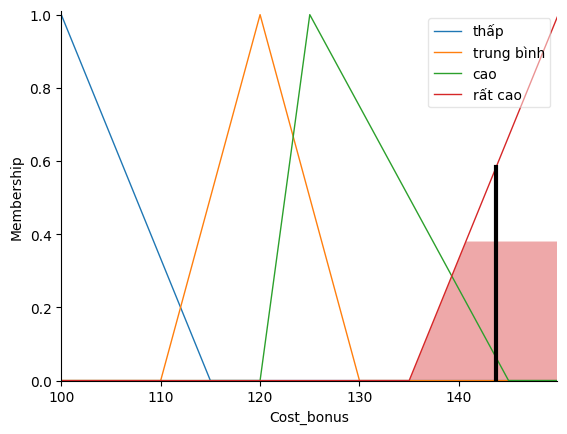

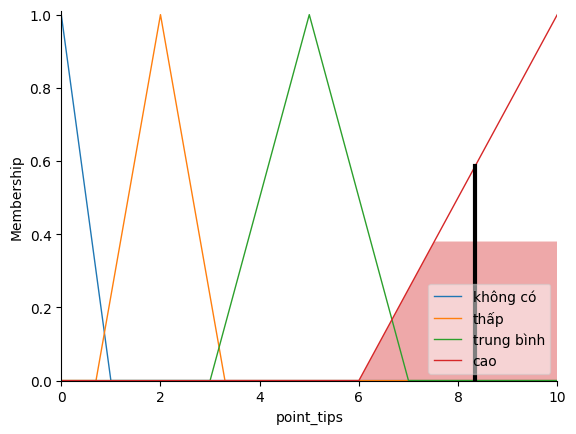

In [2]:
# Bài 2.11
!pip install scikit-fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
Ride_Distance=ctrl.Antecedent(np.arange(0,50.1,0.1),"Ride_Distance")
Traffic_Condition=ctrl.Antecedent(np.arange(0,100.1,0.1),"Traffic_Condition")
Demand_Level=ctrl.Antecedent(np.arange(0,100.1,0.1),"Demand_Level")
Weather_Condition=ctrl.Antecedent(np.arange(0,10.1,0.1),"Weather_Condition")
Customer_Rating=ctrl.Antecedent(np.arange(1,5.1,0.1),"Customer_Rating")
Ride_Punctuality=ctrl.Antecedent(np.arange(0,100.1,0.1),"Ride_Punctuality")
Cost_bonus=ctrl.Consequent(np.arange(100,150,0.1),"Cost_bonus")
point_tips=ctrl.Consequent(np.arange(0,10.1,0.1),"point_tips")
Ride_Distance["ngắn"]=fuzz.trimf(Ride_Distance.universe,[0,0,3])
Ride_Distance["trung bình"]=fuzz.trimf(Ride_Distance.universe,[2,5,8])
Ride_Distance["dài"]=fuzz.trimf(Ride_Distance.universe,[6,13,20])
Ride_Distance["rất dài"]=fuzz.trimf(Ride_Distance.universe,[15,50,50])
Traffic_Condition["thấp"]=fuzz.trimf(Traffic_Condition.universe,[0,0,30])
Traffic_Condition["trung bình"]=fuzz.trimf(Traffic_Condition.universe,[20,45,70])
Traffic_Condition["cao"]=fuzz.trimf(Traffic_Condition.universe,[60,100,100])
Demand_Level["thấp"]=fuzz.trimf(Demand_Level.universe,[0,0,30])
Demand_Level["trung bình"]=fuzz.trimf(Demand_Level.universe,[20,45,70])
Demand_Level["cao"]=fuzz.trimf(Demand_Level.universe,[60,100,100])
Weather_Condition["tệ"]=fuzz.trimf(Weather_Condition.universe,[0,0,5])
Weather_Condition["tạm"]=fuzz.trimf(Weather_Condition.universe,[4,6,8])
Weather_Condition["tốt"]=fuzz.trimf(Weather_Condition.universe,[7,10,10])
Customer_Rating["tệ"]=fuzz.trimf(Customer_Rating.universe,[1,1,2.5])
Customer_Rating["trung bình"]=fuzz.trimf(Customer_Rating.universe,[2,3,4])
Customer_Rating["tốt"]=fuzz.trimf(Customer_Rating.universe,[3.5,5,5])
Ride_Punctuality["trễ"]=fuzz.trimf(Ride_Punctuality.universe,[0,0,50])
Ride_Punctuality["đúng giờ"]=fuzz.trimf(Ride_Punctuality.universe,[40,60,80])
Ride_Punctuality["sớm"]=fuzz.trimf(Ride_Punctuality.universe,[70,100,100])
Cost_bonus["thấp"]=fuzz.trimf(Cost_bonus.universe,[100,100,115])
Cost_bonus["trung bình"]=fuzz.trimf(Cost_bonus.universe,[110,120,130])
Cost_bonus["cao"]=fuzz.trimf(Cost_bonus.universe,[120,125,145])
Cost_bonus["rất cao"]=fuzz.trimf(Cost_bonus.universe,[135,150,150])
point_tips["không có"]=fuzz.trimf(point_tips.universe,[0,0,1])
point_tips["thấp"]=fuzz.trimf(point_tips.universe,[0.7,2,3.3])
point_tips["trung bình"]=fuzz.trimf(point_tips.universe,[3,5,7])
point_tips["cao"]=fuzz.trimf(point_tips.universe,[6,10,10])
Rules = [
    ctrl.Rule(Ride_Distance["ngắn"] & Traffic_Condition["thấp"] & Demand_Level["thấp"], Cost_bonus["thấp"]),
    ctrl.Rule(Ride_Distance["ngắn"] & Traffic_Condition["trung bình"] & Demand_Level["cao"], Cost_bonus["trung bình"]),
    ctrl.Rule(Ride_Distance["trung bình"] & Traffic_Condition["cao"] & Demand_Level["cao"], Cost_bonus["cao"]),
    ctrl.Rule(Ride_Distance["dài"] & Traffic_Condition["trung bình"] & Weather_Condition["tốt"], Cost_bonus["trung bình"]),
    ctrl.Rule(Ride_Distance["dài"] & Traffic_Condition["cao"] & Weather_Condition["tệ"], Cost_bonus["rất cao"]),
    ctrl.Rule(Ride_Distance["rất dài"] & Traffic_Condition["cao"] & Demand_Level["cao"], Cost_bonus["rất cao"]),
    ctrl.Rule(Ride_Distance["trung bình"] & Traffic_Condition["thấp"] & Demand_Level["thấp"], Cost_bonus["trung bình"]),
    ctrl.Rule(Ride_Distance["ngắn"] & Traffic_Condition["cao"] & Weather_Condition["tệ"], Cost_bonus["cao"]),
    ctrl.Rule(Ride_Distance["rất dài"] & Weather_Condition["tệ"], Cost_bonus["rất cao"]),
    ctrl.Rule(Ride_Distance["trung bình"] & Traffic_Condition["trung bình"] & Weather_Condition["tạm"], Cost_bonus["trung bình"]),
    ctrl.Rule(Customer_Rating["tốt"] & Ride_Punctuality["sớm"], point_tips["cao"]),
    ctrl.Rule(Customer_Rating["trung bình"] & Ride_Punctuality["đúng giờ"], point_tips["trung bình"]),
    ctrl.Rule(Customer_Rating["tệ"], point_tips["không có"]),
    ctrl.Rule(Ride_Distance["dài"] & Traffic_Condition["cao"] & Ride_Punctuality["đúng giờ"], point_tips["cao"]),
    ctrl.Rule(Ride_Distance["trung bình"] & Traffic_Condition["cao"] & Customer_Rating["tốt"], point_tips["trung bình"]),
    ctrl.Rule(Customer_Rating["tệ"] & Ride_Punctuality["trễ"], point_tips["không có"]),
    ctrl.Rule(Ride_Distance["rất dài"] & Weather_Condition["tệ"] & Customer_Rating["tốt"], point_tips["cao"]),
    ctrl.Rule(Ride_Distance["ngắn"] & Customer_Rating["trung bình"] & Ride_Punctuality["đúng giờ"], point_tips["thấp"]),
    ctrl.Rule(Ride_Distance["dài"] & Traffic_Condition["cao"] & Ride_Punctuality["trễ"], point_tips["thấp"]) ,
    ctrl.Rule(Ride_Distance["trung bình"] & Weather_Condition["tạm"] & Customer_Rating["tốt"], point_tips["trung bình"]),
    ]
Rule_app_ctrl=ctrl.ControlSystem(Rules)
evaluation=ctrl.ControlSystemSimulation(Rule_app_ctrl)
evaluation.input["Ride_Distance"]=38
evaluation.input["Traffic_Condition"]=54
evaluation.input["Demand_Level"]=17.7
evaluation.input["Weather_Condition"]=3.1
evaluation.input["Customer_Rating"]=4.1
evaluation.input["Ride_Punctuality"]=71
evaluation.compute()
he_so_thuong = evaluation.output["Cost_bonus"]
quang_duong = 37
gia_cuoi_cung = he_so_thuong/100 * quang_duong * 5000
print(f"Giá_cần_phải_trả:{gia_cuoi_cung:,.0f} VND")
print(f"Điểm_nhận_được_khi_shipper_hoàn_thành_đơn_hàng:{evaluation.output["point_tips"]:.2f}")
Cost_bonus.view(sim=evaluation)
point_tips.view(sim=evaluation)

====== KẾT QUẢ MÔ PHỎNG ======
Mức chiết khấu đề xuất: 55.53%


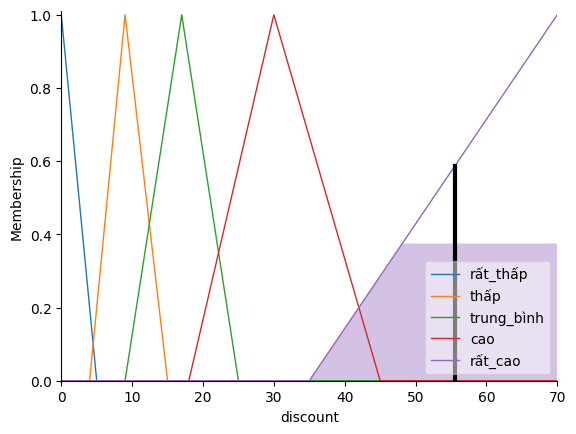

In [ ]:
# Bài 2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
volume = ctrl.Antecedent(np.arange(0, 1001, 1), 'volume')
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')
event = ctrl.Antecedent(np.arange(0, 11, 1), 'event')
competitor = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor')
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')
rating['thấp'] = fuzz.trimf(rating.universe, [0, 0, 4.0])
rating['trung_bình'] = fuzz.trimf(rating.universe, [3.8, 4.25, 4.6])
rating['cao'] = fuzz.trimf(rating.universe, [4.4, 5.0, 5.0])
volume['thấp'] = fuzz.trimf(volume.universe, [0, 0, 400])
volume['trung_bình'] = fuzz.trimf(volume.universe, [200, 500, 800])
volume['cao'] = fuzz.trimf(volume.universe, [600, 1000, 1000])
margin['thấp'] = fuzz.trimf(margin.universe, [0, 0, 30])
margin['trung_bình'] = fuzz.trimf(margin.universe, [20, 50, 80])
margin['cao'] = fuzz.trimf(margin.universe, [60, 100, 100])
event['không_có'] = fuzz.trimf(event.universe, [0, 0, 3])
event['trung_bình'] = fuzz.trimf(event.universe, [2, 5, 8])
event['cao'] = fuzz.trimf(event.universe, [7, 10, 10])
competitor['thấp'] = fuzz.trimf(competitor.universe, [0, 0, 40])
competitor['trung_bình'] = fuzz.trimf(competitor.universe, [20, 50, 80])
competitor['cao'] = fuzz.trimf(competitor.universe, [60, 100, 100])
discount['rất_thấp'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['thấp'] = fuzz.trimf(discount.universe, [4, 9, 15])
discount['trung_bình'] = fuzz.trimf(discount.universe, [9, 17, 25])
discount['cao'] = fuzz.trimf(discount.universe, [18, 30, 45])
discount['rất_cao'] = fuzz.trimf(discount.universe, [35, 70, 70])
rule1 = ctrl.Rule(rating['cao'] & volume['cao'] & margin['cao'], discount['rất_thấp'])
rule2 = ctrl.Rule(rating['thấp'] & volume['thấp'] & margin['cao'], discount['cao'])
rule3 = ctrl.Rule(event['cao'] & competitor['cao'], discount['rất_cao'])
rule4 = ctrl.Rule(rating['trung_bình'] & volume['trung_bình'] & margin['trung_bình'], discount['trung_bình'])
rule5 = ctrl.Rule(competitor['thấp'] & margin['thấp'] & volume['cao'], discount['rất_thấp'])
rule6 = ctrl.Rule(rating['thấp'] & event['không_có'], discount['trung_bình'])
rule7 = ctrl.Rule(volume['thấp'] & margin['thấp'], discount['rất_cao'])
discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)
discount_sim.input['rating'] = 4.3
discount_sim.input['volume'] = 555
discount_sim.input['margin'] = 16
discount_sim.input['event'] = 9.5
discount_sim.input['competitor'] = 75
discount_sim.compute()
print("====== KẾT QUẢ MÔ PHỎNG ======")
print(f"Mức chiết khấu đề xuất: {discount_sim.output['discount']:.2f}%")
discount.view(sim=discount_sim)

Mức chiết khấu tính toán được: 15.00%


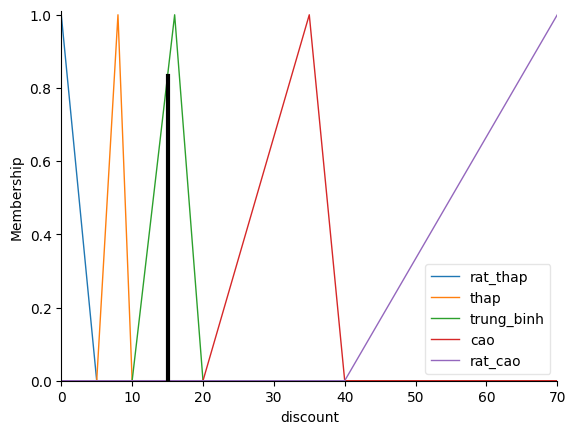

In [ ]:
#BÀI 2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
demand = ctrl.Antecedent(np.arange(0, 11, 1), 'demand')
pressure = ctrl.Antecedent(np.arange(0, 11, 1), 'pressure')
reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'reputation')
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')
seasonal = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal')
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')
demand['thap'] = fuzz.trimf(demand.universe, [0, 0, 4])
demand['trung_binh'] = fuzz.trimf(demand.universe, [2, 5, 8])
demand['cao'] = fuzz.trimf(demand.universe, [6, 10, 10])
pressure['thap'] = fuzz.trimf(pressure.universe, [0, 0, 4])
pressure['trung_binh'] = fuzz.trimf(pressure.universe, [2, 5, 8])
pressure['cao'] = fuzz.trimf(pressure.universe, [6, 10, 10])
reputation['thap'] = fuzz.trimf(reputation.universe, [0, 0, 3.9])
reputation['trung_binh'] = fuzz.trimf(reputation.universe, [3.8, 4.25, 4.6])
reputation['cao'] = fuzz.trimf(reputation.universe, [4.5, 5.0, 5.0])
margin['thap'] = fuzz.trimf(margin.universe, [0, 0, 30])
margin['trung_binh'] = fuzz.trimf(margin.universe, [20, 50, 80])
margin['cao'] = fuzz.trimf(margin.universe, [60, 100, 100])
seasonal['khong_co'] = fuzz.trimf(seasonal.universe, [0, 0, 2])
seasonal['trung_binh'] = fuzz.trimf(seasonal.universe, [2, 5, 7.5])
seasonal['cao'] = fuzz.trimf(seasonal.universe, [7.5, 10, 10])
discount['rat_thap'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['thap'] = fuzz.trimf(discount.universe, [5, 8, 10])
discount['trung_binh'] = fuzz.trimf(discount.universe, [10, 16, 20])
discount['cao'] = fuzz.trimf(discount.universe, [20, 35, 40])
discount['rat_cao'] = fuzz.trimf(discount.universe, [40, 70, 70])
rule1 = ctrl.Rule(demand['cao'] & pressure['thap'] & margin['thap'], discount['rat_thap'])
rule2 = ctrl.Rule(demand['thap'] & pressure['cao'] & margin['cao'], discount['cao'])
rule3 = ctrl.Rule(reputation['cao'] & margin['trung_binh'] & seasonal['cao'], discount['trung_binh'])
rule4 = ctrl.Rule(pressure['cao'] & seasonal['cao'] & margin['cao'], discount['rat_cao'])
rule5 = ctrl.Rule(reputation['thap'] & demand['trung_binh'] & margin['thap'], discount['trung_binh'])
rule6 = ctrl.Rule(demand['cao'] & seasonal['khong_co'] & pressure['thap'], discount['rat_thap'])
rule7 = ctrl.Rule(margin['cao'] & pressure['trung_binh'] & seasonal['trung_binh'], discount['trung_binh'])
special_discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
special_discount_sim = ctrl.ControlSystemSimulation(special_discount_ctrl)
special_discount_sim.input['demand'] = 10
special_discount_sim.input['pressure'] = 5.5
special_discount_sim.input['reputation'] = 4.2
special_discount_sim.input['margin'] = 79
special_discount_sim.input['seasonal'] = 7.99
special_discount_sim.compute()
print(f"Mức chiết khấu tính toán được: {special_discount_sim.output['discount']:.2f}%")
discount.view(sim=special_discount_sim)

-> Mức độ Kết hợp đơn hàng : 8.24 / 10
-> Mức độ Ưu tiên giao hàng: 5.00 / 10


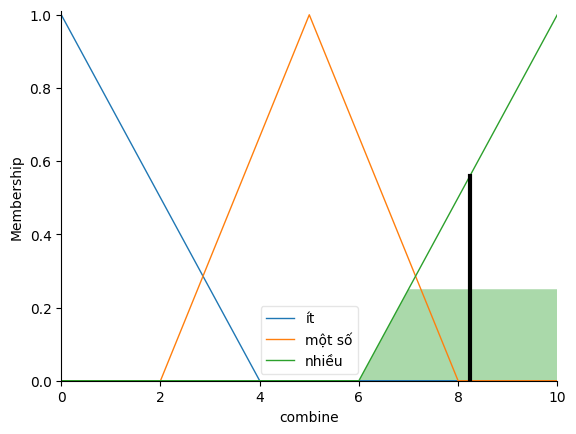

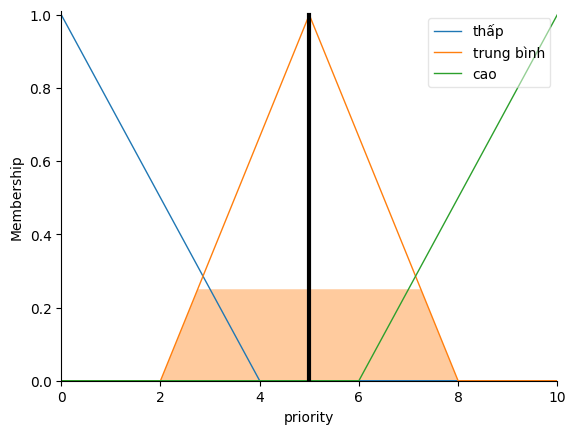

In [ ]:
#BÀI 2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
density = ctrl.Antecedent(np.arange(0, 101, 1), 'density')
urgency = ctrl.Antecedent(np.arange(0, 11, 1), 'urgency')
load = ctrl.Antecedent(np.arange(0, 101, 1), 'load')
traffic = ctrl.Antecedent(np.arange(0, 81, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 1001, 1), 'profit')
combine = ctrl.Consequent(np.arange(0, 11, 1), 'combine')
priority = ctrl.Consequent(np.arange(0, 11, 1), 'priority')
density['thấp'] = fuzz.trimf(density.universe, [0, 0, 40])
density['trung bình'] = fuzz.trimf(density.universe, [20, 50, 80])
density['cao'] = fuzz.trimf(density.universe, [60, 100, 100])
urgency['thấp'] = fuzz.trimf(urgency.universe, [0, 0, 4])
urgency['trung bình'] = fuzz.trimf(urgency.universe, [2, 5, 8])
urgency['cao'] = fuzz.trimf(urgency.universe, [6, 10, 10])
load['thấp'] = fuzz.trimf(load.universe, [0, 0, 40])
load['trung bình'] = fuzz.trimf(load.universe, [20, 50, 80])
load['cao'] = fuzz.trimf(load.universe, [60, 100, 100])
traffic['cao'] = fuzz.trimf(traffic.universe, [0, 0, 20])
traffic['trung bình'] = fuzz.trimf(traffic.universe, [10, 30, 50])
traffic['thấp'] = fuzz.trimf(traffic.universe, [25, 80, 80])
profit['thấp'] = fuzz.trimf(profit.universe, [0, 0, 400])
profit['trung bình'] = fuzz.trimf(profit.universe, [200, 500, 800])
profit['cao'] = fuzz.trimf(profit.universe, [600, 1000, 1000])
combine['ít'] = fuzz.trimf(combine.universe, [0, 0, 4])
combine['một số'] = fuzz.trimf(combine.universe, [2, 5, 8])
combine['nhiều'] = fuzz.trimf(combine.universe, [6, 10, 10])
priority['thấp'] = fuzz.trimf(priority.universe, [0, 0, 4])
priority['trung bình'] = fuzz.trimf(priority.universe, [2, 5, 8])
priority['cao'] = fuzz.trimf(priority.universe, [6, 10, 10])
rule1 = ctrl.Rule(density['cao'] & load['thấp'] & traffic['cao'], combine['nhiều'])
rule2 = ctrl.Rule(density['trung bình'] & traffic['cao'] & urgency['trung bình'], combine['một số'])
rule3 = ctrl.Rule(load['cao'] & density['cao'] & profit['trung bình'], combine['một số'])
rule4 = ctrl.Rule(density['thấp'] & urgency['cao'] & traffic['trung bình'], combine['một số'])
rule5 = ctrl.Rule(profit['cao'] & urgency['cao'] & traffic['cao'], combine['một số'])
rule6 = ctrl.Rule(urgency['cao'] & profit['cao'], priority['cao'])
rule7 = ctrl.Rule(urgency['trung bình'] & traffic['trung bình'], priority['trung bình'])
rule8 = ctrl.Rule(urgency['thấp'] & density['cao'] & profit['thấp'], priority['thấp'])
logistics_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)
logistics_sim.input['density'] = 85
logistics_sim.input['urgency'] = 5
logistics_sim.input['load'] = 20
logistics_sim.input['traffic'] = 15
logistics_sim.input['profit'] = 500
logistics_sim.compute()
print(f"-> Mức độ Kết hợp đơn hàng : {logistics_sim.output['combine']:.2f} / 10")
print(f"-> Mức độ Ưu tiên giao hàng: {logistics_sim.output['priority']:.2f} / 10")
combine.view(sim=logistics_sim)
priority.view(sim=logistics_sim)